In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
d_df = pd.read_csv("cleaned_data\\data.csv")

In [4]:
d_df.head()

,Make,Model,Year,Engine_HP,Engine_Cylinders,Transmission_Type,Driven_Wheels,Number_of_Doors,Market_Category,Vehicle_Size,Vehicle_Style,highway_MPG,city_mpg,Popularity,MSRP,Fuel_Type,price_category,avg_mpg
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,RWD,2.0,High-Performance,Compact,Coupe,26,19,3916,46135,petrol,Medium,22.5
1,BMW,1 Series,2011,300.0,6.0,MANUAL,RWD,2.0,Performance,Compact,Convertible,28,19,3916,40650,petrol,Medium,23.5
2,BMW,1 Series,2011,300.0,6.0,MANUAL,RWD,2.0,High-Performance,Compact,Coupe,28,20,3916,36350,petrol,Medium,24.0
3,BMW,1 Series,2011,230.0,6.0,MANUAL,RWD,2.0,Performance,Compact,Coupe,28,18,3916,29450,petrol,Medium,23.0
4,BMW,1 Series,2011,230.0,6.0,MANUAL,RWD,2.0,Luxury,Compact,Convertible,28,18,3916,34500,petrol,Medium,23.0


In [5]:
d_df.columns

Index(['Make', 'Model', 'Year', 'Engine_HP', 'Engine_Cylinders',
       'Transmission_Type', 'Driven_Wheels', 'Number_of_Doors',
       'Market_Category', 'Vehicle_Size', 'Vehicle_Style', 'highway_MPG',
       'city_mpg', 'Popularity', 'MSRP', 'Fuel_Type', 'price_category',
       'avg_mpg'],
      dtype='str')

## 1. Top 10 cars vs sales counts

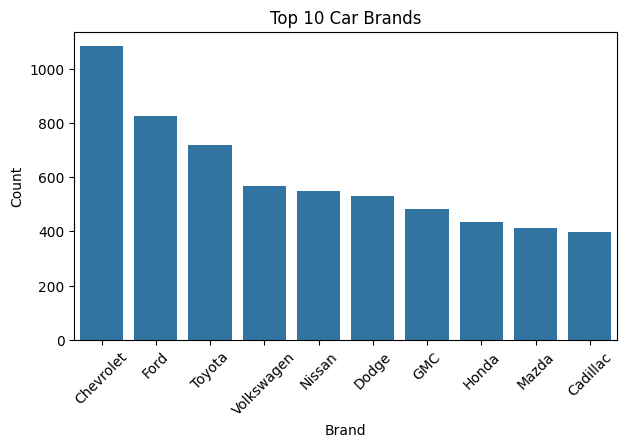

In [6]:
plt.figure(figsize=(7,4))
top_10 = d_df['Make'].value_counts().head(10)
sns.barplot(x=top_10.index,y=top_10.values)
plt.title('Top 10 Car Brands')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Observation**

the sales is dominate by Chevrolet followed by Ford and Toyota

## 2. plot the sales distribution on price category

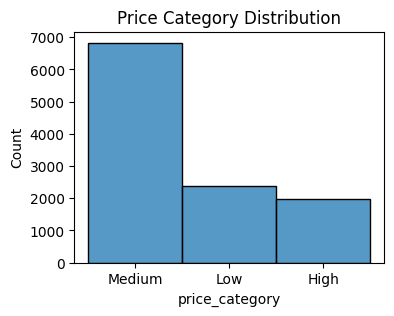

In [7]:
plt.figure(figsize=(4,3))
sns.histplot(d_df,x='price_category')
plt.title("Price Category Distribution")
plt.show()

**Observation**

The Most people buying the medium amount range cars only 

## 3. Vehicle Style wise sales

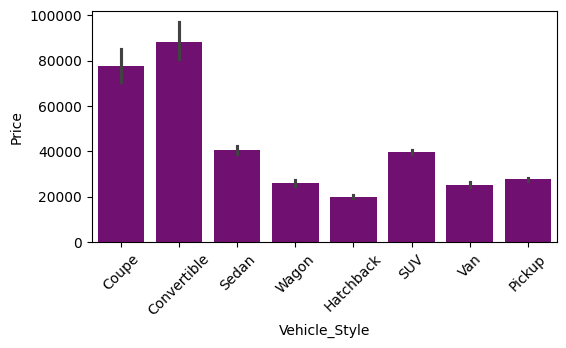

In [8]:
plt.figure(figsize=(6,3))
sns.barplot(d_df,x='Vehicle_Style',y='MSRP',color='purple')

plt.xticks(rotation=45)
plt.ylabel("Price")
plt.show()

**Observation**

Convertibles have the highest average price among all vehicle styles

## 4. plot the portion of vehicle size

In [9]:
s = d_df['Vehicle_Size'].value_counts()

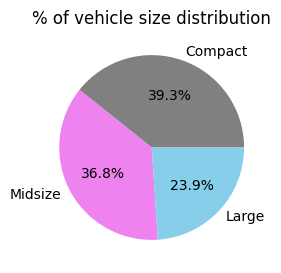

In [10]:
plt.figure(figsize=(3,3))
plt.pie(x=s.values,labels=s.index,autopct="%.1f%%",colors=['grey','violet','skyblue'])
plt.title("% of vehicle size distribution")
plt.show()

**Observation**

The compact vehicle are top of the sales followed by midsize and large size vehicles

## 5. Trend analysis year wise sales

In [11]:
year = d_df['Year'].value_counts().sort_index()

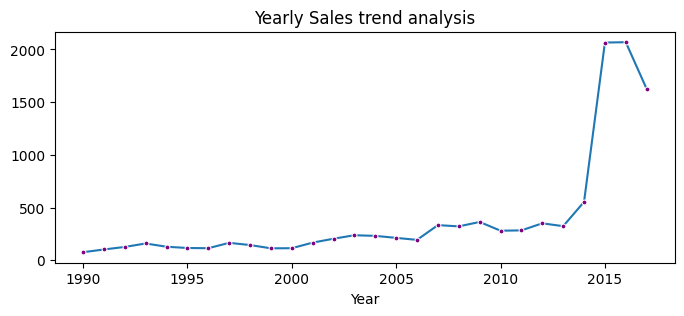

In [12]:
plt.figure(figsize=(8,3))
sns.lineplot(x=year.index,y=year.values,linestyle='-',marker='.',markersize=7,markerfacecolor='purple')
plt.title("Yearly Sales trend analysis")

plt.show()

**Observation**

Sales show a gradual increase, with a sharp rise after 2014

## 6. i. relationship bw price and driven wheels
#     ii. relationship bw price and fuel type

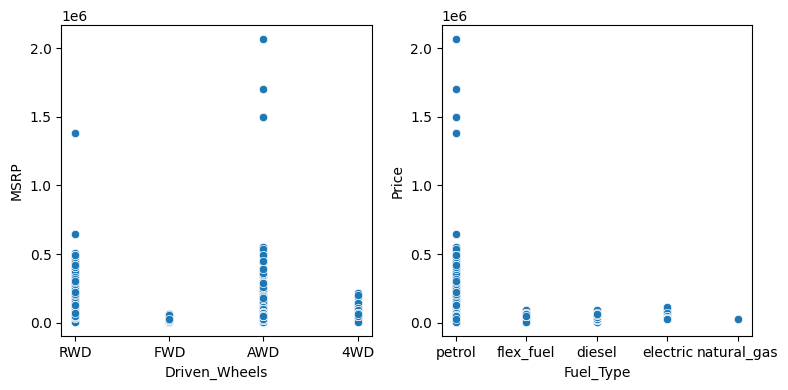

In [13]:
f,a=plt.subplots(1,2, figsize=(8,4))
sns.scatterplot(d_df,y='MSRP',x='Driven_Wheels',ax=a[0])
plt.ylabel("Price")

sns.scatterplot(d_df,y='MSRP',x='Fuel_Type',ax=a[1])

plt.ylabel("Price")
plt.tight_layout()
plt.show()

**Observation**

RWD cars have the widest price range, including the highest MSRP values

Petrol cars dominate the dataset and span the full price range including top outliers

## 7. detect the outliers

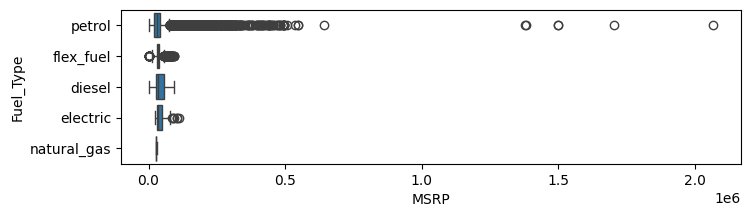

In [14]:
plt.figure(figsize=(8,2))
sns.boxplot(data=d_df, y='Fuel_Type', x="MSRP")
plt.show()

**Observation**

Petrol vehicle has the most outliers by far — many data points scattered far to the right 

## 8. plot the transmission wise avg sales for each market category

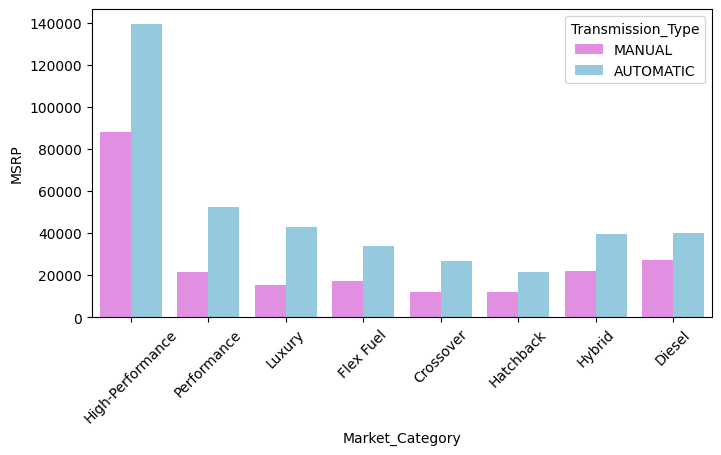

In [15]:
plt.figure(figsize=(8,4))
sns.barplot(data=d_df, x='Market_Category' , y='MSRP',estimator='mean',hue='Transmission_Type',
            palette=['violet','skyblue'],errorbar=None)

plt.xticks(rotation=45)
plt.show()

**Observation**

High-Performance vehicles dominating all other category vehicles

manual and also automatic both dominating in high performance

## 9. i. correlation bw avg mph and Engine_Cylinders
##   ii. correlation bw Engine_HP and Price

In [16]:
cr = d_df.corr(numeric_only=True)

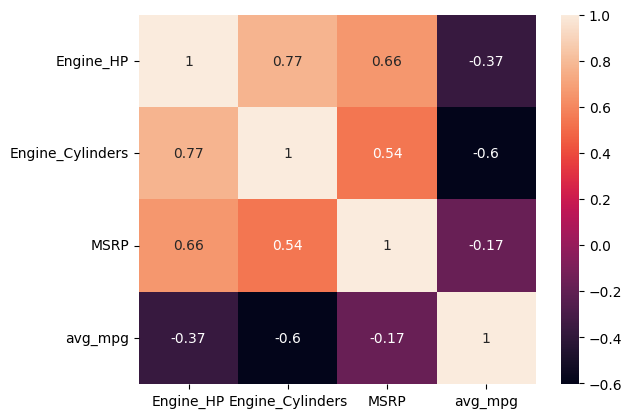

In [17]:
cr1=cr.loc[['Engine_HP','Engine_Cylinders','MSRP','avg_mpg'],['Engine_HP','Engine_Cylinders','MSRP','avg_mpg']]
sns.heatmap(cr1,annot=True)
plt.show()

**Observation**

avg_mpg and Engine_Cylinders = -0.6 → More cylinders = worse fuel efficiency, strong inverse relationship

Engine_HP and Price = 0.66 → Higher HP cars are significantly more expensive

## CONCLUSION

This analysis of the Car Sales dataset reveals that Chevrolet, Ford, and Toyota dominate overall sales, 
with most buyers preferring compact, medium-priced vehicles.

Convertibles and High-Performance vehicles command the highest Price, with RWD and
petrol-powered cars spanning the full premium price range including extreme outliers.

Automatic transmission consistently fetches higher prices across all market categories, 
especially in the High-Performance segment. 

Engine HP strongly drives both price and fuel inefficiency , confirming that 
more power means higher cost and lower fuel economy across the dataset.